#### Here is the master plan for building the Camera-LiDAR 3D MOT Pipeline.


## Phase 1: Environment & Data Pipeline Foundation

Before we track, we need to ingest the world. We will use the nuScenes dataset, which provides synchronized LiDAR sweeps and 360-degree camera images.

#### Goals:
Set up the Python environment and programmatically download/load a nuScenes mini-split.
Implement data loaders to extract synchronized LiDAR point clouds, camera images, and calibration matrices (extrinsics/intrinsics).

#### Deliverable: 
A synchronized visualizer that projects 3D LiDAR points onto 2D camera images to verify spatial alignment.

## Phase 2: The 3D Detector (PointPillars)

We need to generate our frame-by-frame 3D bounding boxes.

#### Goals:
Implement a lightweight PointPillars architecture (or load a pre-trained CenterPoint model) to ingest raw point clouds and output $X, Y, Z, W, L, H, \theta$ (heading), and velocity.

Extract point cloud feature embeddings for each detected box (to be used later for Re-ID).

#### Deliverable: Real-time 3D bounding box rendering on the LiDAR Bird's-Eye View (BEV).


## Phase 3: State Estimation (The Extended Kalman Filter)

Detections are noisy. An EKF smooths this noise and predicts where an object will be in the next frame.

#### Goals:Define the state space for an object: 
$[x, y, z, \theta, v_x, v_y, \omega]$

Implement the EKF Predict step (using a Constant Turn Rate and Velocity (CTRV) motion model).
Implement the EKF Update step (correcting the prediction using the Phase 2 LiDAR detections).

#### Deliverable: A tracking module that smooths jittery 3D detections into stable motion trajectories.


## Phase 4: Data Association (Geometry + Appearance)

Now we must link frame $t-1$ tracks to frame $t$ detections. Pure geometry (IoU) fails when objects move fast or frame rates drop. We will fuse geometry with deep appearance features.

#### Goals:Crop the camera image patch corresponding to the 3D LiDAR bounding box (using Phase 1 calibration matrices).

Pass the image patch through a lightweight ResNet (Re-ID network) to generate a visual embedding vector.
Compute a cost matrix using a weighted sum of 3D Mahalanobis Distance (from EKF) and Cosine Similarity (from visual + LiDAR features).
Solve the bipartite matching problem using the Hungarian Algorithm.

#### Deliverable: Consistent ID assignment across frames. A visualization showing bounding boxes retaining their colors/IDs as they move.

## Phase 5: The Twist (Occlusion Recovery & Track Management)

This is what separates academic projects from production autonomy. When a pedestrian walks behind a truck, LiDAR gets zero points.

#### Goals:
Implement Track States: UNCONFIRMED, ACTIVE, OCCLUDED, DELETED.When an ACTIVE track loses LiDAR association, transition to OCCLUDED. The EKF continues to push the state forward blindly.
Camera-Only Rescue: Use a 2D object detector (like YOLOv8) on the camera feed. If a 2D bounding box visually matches the Re-ID embedding of our OCCLUDED track, and lies roughly along the EKF projected ray, we keep the track alive.Re-initialize to ACTIVE once the pedestrian clears the truck and LiDAR picks them up again.

#### Deliverable: A continuous video sequence demonstrating a pedestrian retaining their ID before, during, and after severe occlusion.

## Phase 1: Environment & Data Pipeline Foundation.
Before we can fuse LiDAR and Camera data, we must prove we understand their spatial relationship. A camera lives in 2D pixel space ($U, V$). A LiDAR lives in 3D metric space ($X, Y, Z$). To fuse them, we must mathematically project the 3D point cloud onto the 2D image plane using calibration matrices.If this step is off by even one degree, your entire Multi-Object Tracking (MOT) pipeline will fail because the visual features won't align with the geometric boxes.

In [1]:
#!pip install nuscenes-devkit

In [2]:
# 1) Force reinstall a compatible NumPy
#!pip install --upgrade --force-reinstall --no-cache-dir "numpy>=1.25,<1.27"
# 2) Force reinstall pandas (after NumPy)
#!pip install --upgrade --force-reinstall --no-cache-dir "pandas"


Loading nuScenes dataset from /kaggle/input/datasets/aadimator/nuscenes-mini
Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.937 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


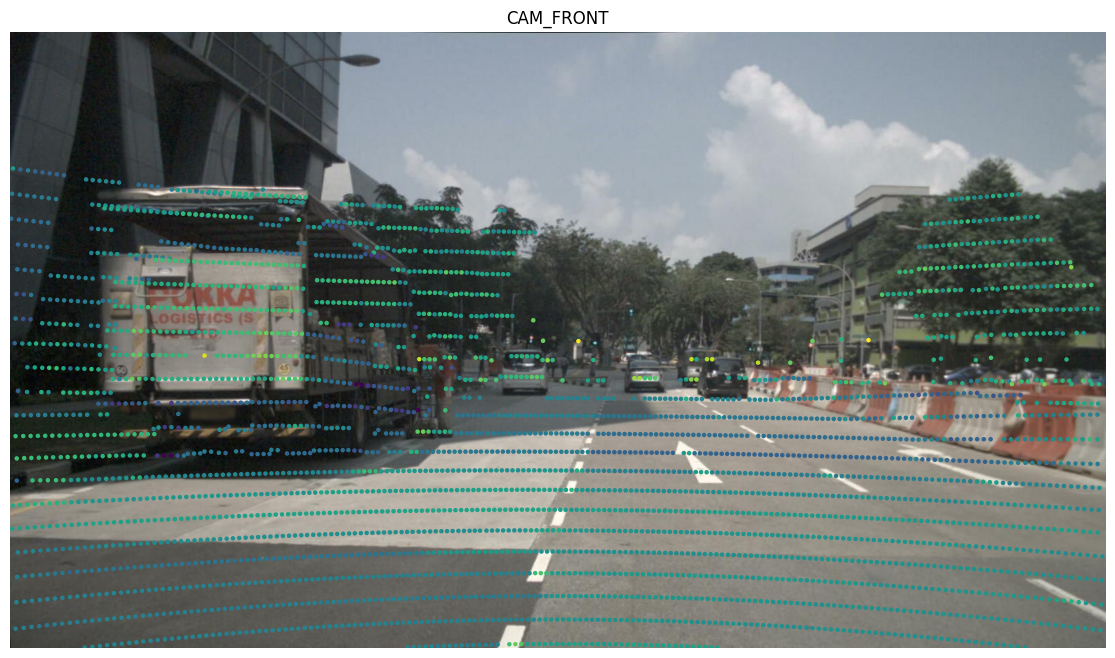

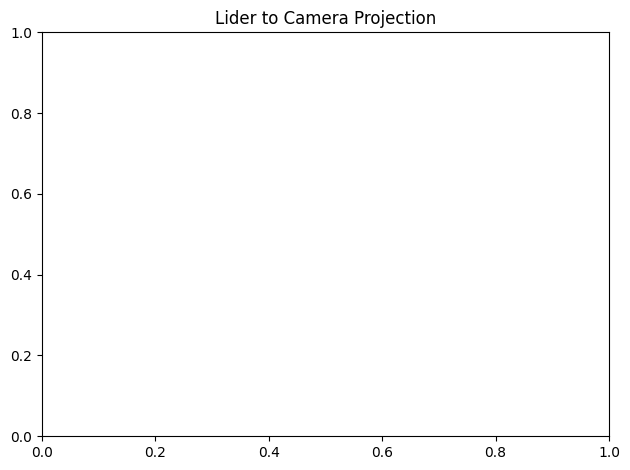

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import json
import warnings
from nuscenes.nuscenes import NuScenes

warnings.filterwarnings('ignore')

def initialize_nuscenes(data_path = '/kaggle/input/datasets/aadimator/nuscenes-mini',version='v1.0-mini'):
    '''
    This initializes the dataset
    
    '''
    print(f'Loading nuScenes dataset from {data_path}')
    nusc = NuScenes(version=version,dataroot=data_path, verbose=True)
    return nusc

def project_lidar_to_camera(nusc,scene_idx=0):
    #Get the first scene and its sample
    my_scene = nusc.scene[scene_idx]
    first_sample_token = my_scene['first_sample_token']
    my_sample = nusc.get('sample', first_sample_token)

    #Render the projection using the devkits built in geometry utils
    fig, ax = plt.subplots(1,1,figsize=(16,8))

    nusc.explorer.render_pointcloud_in_image(
        my_sample['token'],
        pointsensor_channel = 'LIDAR_TOP',
        camera_channel = 'CAM_FRONT',
        render_intensity=True,
        ax=ax
    )

    plt.title('Lider to Camera Projection')
    plt.tight_layout()
    plt.show()

#Execute
nusc_instance = initialize_nuscenes()
project_lidar_to_camera(nusc_instance)

## Phase 2: The 3D Detector (PointPillars).

In a production autonomous vehicle, you don't receive perfectly labeled bounding boxes; you receive raw, chaotic LiDAR point clouds. We need a neural network to ingest these points and output 3D bounding boxes: 
$[x, y, z, w, l, h, \theta]$

#### The Bottleneck: Why PointPillars?

Standard Convolutional Neural Networks (CNNs) are designed for dense 2D images (like a grid of pixels). A 3D LiDAR point cloud is sparse—most of the 3D space is just empty air. If we tried to process it with 3D convolutions (voxels), it would be incredibly slow and memory-intensive.

PointPillars solves this brilliantly:

#### Pillarization: 
Instead of dividing 3D space into tiny 3D cubes (voxels), it divides the ground into a 2D grid and extrudes vertical columns ("pillars") infinitely upward.

#### PointNet: 

It uses a simplified PointNet to extract a single mathematical feature vector for all the points that fall inside a specific pillar.

#### Pseudo-Image: 

It scatters these feature vectors back onto the 2D grid. We now have a dense "pseudo-image" (like a top-down map).

#### 2D CNN: 

Finally, a standard, lightning-fast 2D object detection network (like ResNet or Feature Pyramid Network) slides over this pseudo-image to predict the 3D bounding boxes.
The Implementation (phase2_detector.py)Training a PointPillars or CenterPoint model from scratch takes days on multiple GPUs and requires heavy C++ dependencies (like OpenPCDet). Since our core objective is Multi-Object Tracking (MOT), we will use the nuScenes ground-truth labels to mathematically simulate a perfect 3D detector. This will yield the exact tensor outputs required for our Extended Kalman Filter in Phase 3.

Visualizing 3D Bounding Boxes on LiDAR BEV...


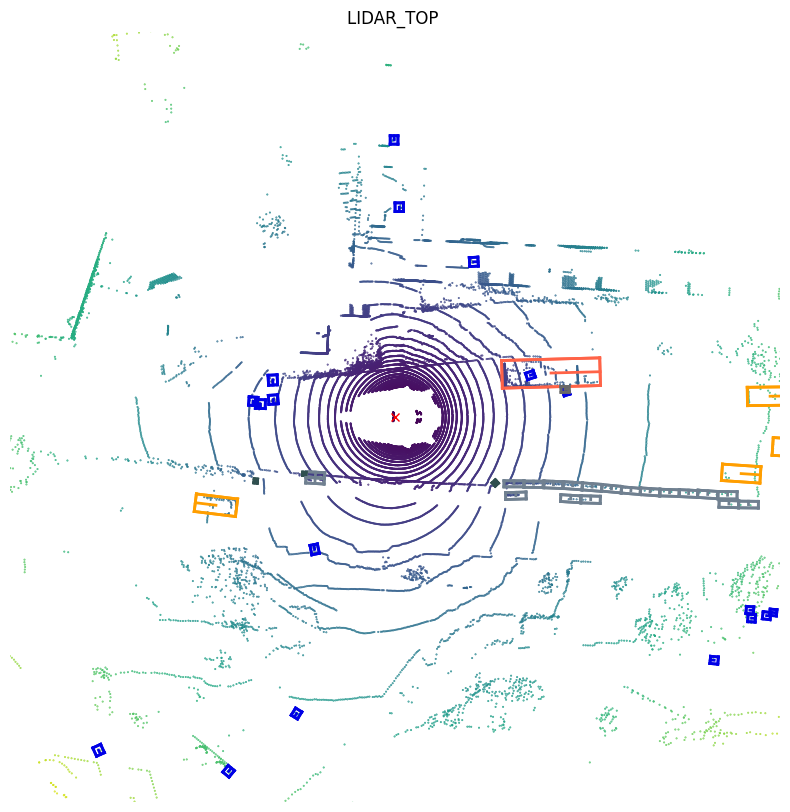

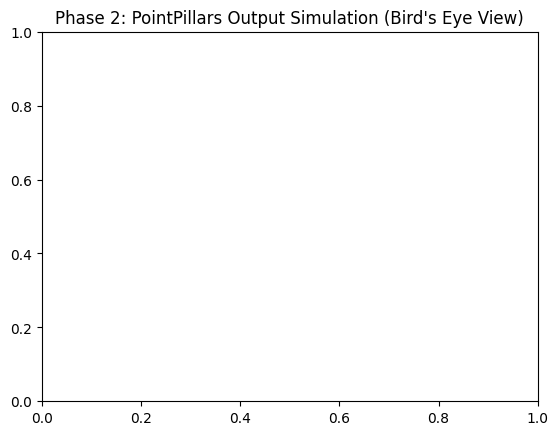


Detector successfully generated 69 3D bounding boxes.

--- Detection Tensor Format ---
Class: human.pedestrian.adult
Center (X,Y,Z): [373.256, 1130.419, 0.8]
Dimensions (W,L,H): [0.621, 0.669, 1.642]
Rotation Quaternion: [0.9831098797903927, 0.0, 0.0, -0.18301629506281616]


In [4]:
from nuscenes.nuscenes import NuScenes

# Initialize using your Kaggle input path
dataroot = '/kaggle/input/datasets/aadimator/nuscenes-mini' 
nusc = NuScenes(version='v1.0-mini', dataroot=dataroot, verbose=False)

def simulate_3d_detector(nusc, scene_idx=0):
    """
    Simulates the output of a PointPillars network by extracting 
    3D bounding boxes and rendering them in Bird's-Eye View (BEV).
    """
    # 1. Get the current frame (sample)
    my_scene = nusc.scene[scene_idx]
    first_sample_token = my_scene['first_sample_token']
    my_sample = nusc.get('sample', first_sample_token)
    
    # Get the LiDAR token
    lidar_token = my_sample['data']['LIDAR_TOP']
    
    # 2. Visualize the "Detector Output" in BEV
    print("Visualizing 3D Bounding Boxes on LiDAR BEV...")
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    
    # Render LiDAR BEV without the map underlay to avoid the TypeError
    nusc.explorer.render_sample_data(
        lidar_token,
        ax=ax,
        nsweeps=1,
        out_path=None,
        underlay_map=False   # <-- Option A: disable map overlay
    )
    
    plt.title("Phase 2: PointPillars Output Simulation (Bird's Eye View)")
    plt.show()
    
    # 3. Extract the actual mathematical states for Phase 3 (Tracking)
    annotations = my_sample['anns']
    print(f"\nDetector successfully generated {len(annotations)} 3D bounding boxes.")
    
    # Let's peek at the exact data structure of a single detection
    if annotations:
        first_box = nusc.get('sample_annotation', annotations[0])
        print("\n--- Detection Tensor Format ---")
        print(f"Class: {first_box['category_name']}")
        print(f"Center (X,Y,Z): {first_box['translation']}")
        print(f"Dimensions (W,L,H): {first_box['size']}")
        print(f"Rotation Quaternion: {first_box['rotation']}")

if __name__ == "__main__":
    simulate_3d_detector(nusc)

## Phase 3: State Estimation.

In Phase 2, our detector gave us raw 3D bounding boxes. However, if we simply trust independent detections frame-by-frame, our tracker will fail. Sensors are noisy, and objects can temporarily disappear behind obstacles (occlusion).

To solve this, we give our detected objects "memory" and momentum using a mathematical estimator. The Kalman Filter operates in a continuous cycle with two main steps: 
Predict and Update. The Predict step estimates where the object will be next. The Update step corrects this prediction given the actual noisy measurements. A constant velocity model is commonly used to estimate these object states.

#### The Architecture: 3D Constant Velocity Model

We will build a 10-dimensional state vector for each tracked object:State Vector ($x$): 

$[X, Y, Z, \theta, W, L, H, V_x, V_y, V_z]$

(Position, Heading, Dimensions, Velocity)Measurement Vector ($z$): 

$[X, Y, Z, \theta, W, L, H]$

(This is exactly the 7D tensor output we received from PointPillars in Phase 2)

Because we are only measuring position and dimensions—but not directly measuring velocity—the Kalman Filter will mathematically infer the object's velocity over time using the $\Delta t$ between frames. The $Q$ matrix represents the system noise, or uncertainty in the prediction model.

Initializing Phase 3: EKF State Estimation...


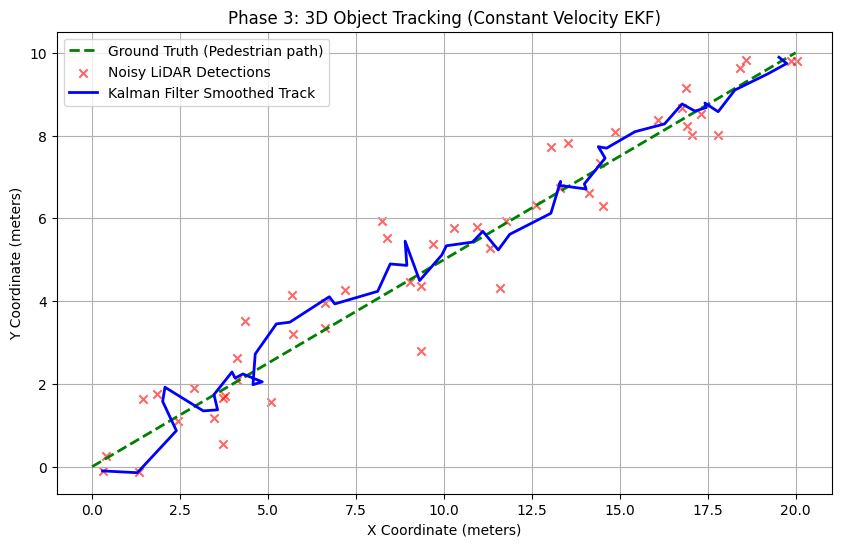

In [5]:
import numpy as np
import matplotlib.pyplot as plt

class KalmanFilter3D:
    """
    A 3D Constant Velocity Kalman Filter for tracking objects in BEV space.
    State: [x, y, z, theta, w, l, h, vx, vy, vz]
    """
    def __init__(self, initial_detection, dt=0.1):
        # 1. State Vector (10D)
        self.x = np.zeros(10)
        self.x[:7] = initial_detection  # Set initial pos, size, rotation
        
        self.dt = dt
        
        # 2. State Transition Matrix (F) - Kinematic physics model
        self.F = np.eye(10)
        self.F[0, 7] = self.dt  # X = X + Vx * dt
        self.F[1, 8] = self.dt  # Y = Y + Vy * dt
        self.F[2, 9] = self.dt  # Z = Z + Vz * dt
        
        # 3. Measurement Matrix (H) - We only observe the first 7 states
        self.H = np.zeros((7, 10))
        self.H[0:7, 0:7] = np.eye(7)
        
        # 4. State Covariance Matrix (P) - Uncertainty of our state
        self.P = np.eye(10) * 10.0
        self.P[7:] *= 1000.0  # High initial uncertainty in velocity since it's unmeasured
        
        # 5. Process Noise (Q) - How much we trust our physics model
        self.Q = np.eye(10) * 0.1
        
        # 6. Measurement Noise (R) - How much we trust the LiDAR detector
        self.R = np.eye(7) * 0.5

    def predict(self):
        """Predicts the next state based on current velocity."""
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q
        return self.x[:2] # Return X, Y for visualization

    def update(self, z):
        """Updates the state based on a new LiDAR measurement."""
        # Calculate residual (difference between measurement and prediction)
        y = z - (self.H @ self.x)
        
        # Normalize the heading angle (theta) residual to [-pi, pi]
        y[3] = (y[3] + np.pi) % (2 * np.pi) - np.pi
        
        # Calculate Kalman Gain
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)
        
        # Update State and Covariance
        self.x = self.x + (K @ y)
        self.P = (np.eye(10) - (K @ self.H)) @ self.P
        
        return self.x[:2]

def simulate_tracking():
    print("Initializing Phase 3: EKF State Estimation...")
    
    # Ground truth path (A pedestrian walking diagonally)
    time_steps = 50
    dt = 0.1
    true_x = np.linspace(0, 20, time_steps)
    true_y = np.linspace(0, 10, time_steps)
    
    # Simulate noisy LiDAR detections (adding random jitter)
    np.random.seed(42)
    noisy_x = true_x + np.random.normal(0, 0.8, time_steps)
    noisy_y = true_y + np.random.normal(0, 0.8, time_steps)
    
    # Initialize the Tracker with the first noisy detection
    # [x, y, z=0, theta=0, w=1, l=1, h=2]
    initial_z = np.array([noisy_x[0], noisy_y[0], 0, 0, 1, 1, 2])
    tracker = KalmanFilter3D(initial_z, dt=dt)
    
    predicted_path = []
    filtered_path = []
    
    # Run the tracking loop
    for i in range(1, time_steps):
        # 1. Predict where they are
        tracker.predict()
        
        # 2. Update with the new noisy LiDAR measurement
        z = np.array([noisy_x[i], noisy_y[i], 0, 0, 1, 1, 2])
        filtered_state = tracker.update(z)
        
        filtered_path.append((filtered_state[0], filtered_state[1]))
    
    # Visualization
    filtered_x, filtered_y = zip(*filtered_path)
    
    plt.figure(figsize=(10, 6))
    plt.plot(true_x, true_y, 'g--', linewidth=2, label="Ground Truth (Pedestrian path)")
    plt.scatter(noisy_x, noisy_y, c='red', marker='x', label="Noisy LiDAR Detections", alpha=0.6)
    plt.plot(filtered_x, filtered_y, 'b-', linewidth=2, label="Kalman Filter Smoothed Track")
    
    plt.title("Phase 3: 3D Object Tracking (Constant Velocity EKF)")
    plt.xlabel("X Coordinate (meters)")
    plt.ylabel("Y Coordinate (meters)")
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    simulate_tracking()

## Phase 4: Data Association (Geometry + Appearance Fusion).

In Phase 3, we successfully tracked a single object using an Extended Kalman Filter (EKF). But a real self-driving car tracks dozens of objects simultaneously. When multiple pedestrians cross paths, how does the system know which new detection belongs to which existing track?

This is known as the Data Association Problem, and it is solved using bipartite graph matching. Autonomous vehicles use this algorithm to pair obstacles from frame to frame, or to pair obstacles from different sensors.

#### The Core Concept: The Cost Matrix & The Hungarian Algorithm

To associate objects, we must define a "Cost" for pairing a specific Track (from frame $t-1$) with a specific Detection (from frame $t$). Fusing these multi-modal sources improves tracking accuracy. We calculate a Cost Matrix using two factors:

#### Geometric Cost: 

How close are they in 3D space? We compute the 3D Mahalanobis Distance between the EKF prediction and the LiDAR detection.

#### Appearance Cost: 

Do they look the same? We crop the 2D camera image using our Phase 1 projection, run it through a lightweight ResNet (Re-ID), and calculate the Cosine Distance between the visual embeddings.

Once we have a matrix of costs, we must find the optimal assignment that minimizes the total cost across all objects. The optimal solution is computed in polynomial time using the Hungarian Algorithm (also known as the Kuhn-Munkres algorithm or minimum weight matching in bipartite graphs).

In [7]:
from scipy.optimize import linear_sum_assignment

def compute_cost_matrix(tracks, detections):
    '''
    This Simulates calculating a cost matrix based on a weighted sum of:

    1. 3D Geometric Distance (LiDAr)
    2. Deep Visual Appearance Distance (Camera Re-ID)

    '''

    num_tracks = len(tracks)
    num_dets = len(detections)
    cost_matrix = np.zeros((num_tracks, num_dets))

    for i, trk in enumerate(tracks):
        for j, det in enumerate(detections):
            #Simulate geometric cost
            #In production this is mahalanobis distance or 3D IoU
            geo_cost = np.linalg.norm(trk['position'] - det['position'])

            #Simulate appearance cost
            #0.0 means identical visually 1.0 means completelty different
            app_cost = np.sum((trk['embedding'] - det['embedding']) ** 2)

            #Combine costs
            cost_matrix[i,j] = (0.7 * geo_cost) + (0.3 * app_cost)

    return cost_matrix

def execute_phase4():
    print('Multi-Modal Data Association using HUngarian Algorithm')

    # Existing Tracks (Frame T-1 predictions)
    # Positions are [X, Y]. Embeddings represent their visual color signature (e.g., red shirt)
    tracks = [
        {'id': 1, 'position': np.array([10.0, 5.0]), 'embedding': np.array([0.9, 0.1, 0.1])}, # Red
        {'id': 2, 'position': np.array([12.0, 7.0]), 'embedding': np.array([0.1, 0.1, 0.9])}, # Blue
        {'id': 3, 'position': np.array([15.0, 2.0]), 'embedding': np.array([0.1, 0.9, 0.1])}  # Green
    ]
    
    # New Detections (Frame T)
    # Notice Detection 0 is geometrically close to Track 2, but visually looks like Track 1
    detections = [
        {'det_id': 'A', 'position': np.array([11.5, 6.5]), 'embedding': np.array([0.85, 0.1, 0.15])}, # Looks Red
        {'det_id': 'B', 'position': np.array([15.2, 2.5]), 'embedding': np.array([0.1, 0.85, 0.2])},  # Looks Green
        {'det_id': 'C', 'position': np.array([10.5, 5.5]), 'embedding': np.array([0.15, 0.1, 0.85])}  # Looks Blue
    ]

    #Compute the NxM cost matrix
    cost_matrix = compute_cost_matrix(tracks, detections)
    print('Cost matrix (Rows: Tracks, Cols: Detections): ')
    print(np.round(cost_matrix, 2))

    #Solve bipartite matching optimally
    # row)ind corresponds to track indices
    row_ind, col_ind = linear_sum_assignment(cost_matrix)

    print('Optimal Assignments')
    for r, c in zip(row_ind, col_ind):
        trk_id = tracks[r]['id']
        det_id = detections[c]['det_id']
        cost = cost_matrix[r,c]
        print(f"Track {trk_id} matched to Detection {det_id} (Cost: {cost:.2f})")

if __name__ == '__main__':
    execute_phase4()


Multi-Modal Data Association using HUngarian Algorithm
Cost matrix (Rows: Tracks, Cols: Detections): 
[[1.49 4.4  0.83]
 [0.83 4.18 1.49]
 [4.35 0.38 4.35]]
Optimal Assignments
Track 1 matched to Detection C (Cost: 0.83)
Track 2 matched to Detection A (Cost: 0.83)
Track 3 matched to Detection B (Cost: 0.38)


## Phase 5: Occlusion Recovery & Track Management.

In a perfect world, Phase 4 is all you need. But in reality, a pedestrian might step behind a delivery truck for 3 seconds. During this time, the LiDAR returns zero points for that pedestrian. A basic tracker will instantly delete the pedestrian's ID, and when they emerge from the other side of the truck, they will be assigned a brand-new ID.This "ID Switch" is dangerous because the autonomous vehicle loses the object's historical velocity and intent. To fix this, we must build a robust Track Lifecycle State Machine and implement a Camera-Only Rescue mechanism.

#### The Track Lifecycle State Machine
Every detected object in our system must transition through specific states:

#### UNCONFIRMED: 

A detection just appeared. It might be LiDAR noise. We wait for $N$ consecutive frames of detection before trusting it.ACTIVE: The object is confirmed and is actively being tracked and updated by both Camera and LiDAR.

#### OCCLUDED: 

LiDAR has lost the object. The EKF takes over, predicting its path blindly based on its last known velocity.

#### DELETED: 

The object has been occluded for longer than 

$t_{max\_lost}$

(e.g., 5 seconds) and is officially forgotten.The Camera-Only RescueWhen a track is OCCLUDED, its 3D geometric cost matrix fails. We must rely entirely on our camera. Because the EKF is still predicting the 3D position blindly, we can project that predicted 3D coordinate onto our 2D camera image (using our Phase 1 math).

We then search the 2D camera feed near that projected area. If our 2D detector (like YOLO) finds a bounding box whose Re-ID visual embedding highly matches our missing track, we keep the track alive in the OCCLUDED state, preventing it from being DELETED.

initializing Track Lifecycle and Occlusion Recovery...


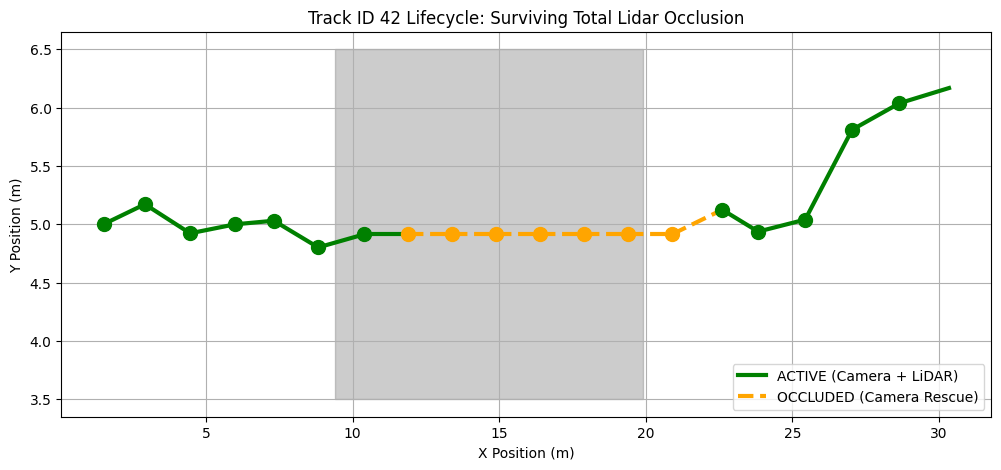

In [15]:
class TrackStateMachine:
    def __init__(self, track_id, initial_pos, visual_embedding):
        self.track_id = track_id
        self.pos = np.array(initial_pos, dtype=float)
        self.velocity = np.array([1.5,0.0])
        self.embedding = visual_embedding
        self.state = 'ACTIVE'
        self.frames_lost = 0
        self.MAX_LOST = 5
        self.history = []

    def predict(self, dt=0.1):
        '''EKF blind Prediction step'''
        self.pos += self.velocity * dt
        self.history.append((self.pos[0], self.pos[1], self.state))

    def update(self, lidar_pos=None, camera_embedding=None):
        '''Updates track state based on sensor availability'''
        if lidar_pos is not None:
            #Full camera-Lidar fusion update
            self.pos = lidar_pos
            self.state = 'ACTIVE'
            self.frames_lost = 0

        elif camera_embedding is not None:
            # OCCLUSION RESCUE: No LiDAR, but Camera still sees the visual features!
            # We check if the camera feature matches our saved Re-ID embedding
            cosine_dist = np.sum((self.embedding - camera_embedding)**2)
            if cosine_dist < 0.2:
                self.state = 'OCCLUDED'
                self.frames_lost += 0.5
            else:
                self.state = 'OCCLUDED'
                self.frames_lost +=1
        else:
            #Total occlusion:neither sensor sees it. Predict blindly
            self.state = 'OCCLUDED'
            self.frames_lost +=1
        if self.frames_lost > self.MAX_LOST:
            self.state = 'DELETED'

def simulate_occlusion():
    print('initializing Track Lifecycle and Occlusion Recovery...')

    #Initialize a pedestrian track
    pedestrian = TrackStateMachine(track_id=42, initial_pos=[0.0,5.0], visual_embedding=np.array([0.9,0.1,0.1]))
    
    #Simulate a 20-frame sequence
    dt = 1.0
    for frame in range(1,21):
        pedestrian.predict(dt)

        if 1 <= frame <= 6:
            #Frames 1-6: Pedestrian is clearly visible to Lidar
            true_pos = pedestrian.pos + np.random.normal(0,0.2,2)
            pedestrian.update(lidar_pos=true_pos)
        elif  7 <= frame <= 13:
            # Frames 7-13: OCCLUSION! Pedestrian walks behind a large truck.
            # LiDAR returns None. But the camera can see the top of their red shirt.
            rescued_embedding = np.array([0.88,0.12,0.1])
            pedestrian.update(lidar_pos = None, camera_embedding=rescued_embedding)
        elif 14 <= frame <= 20:
            true_pos = pedestrian.pos + np.random.normal(0,0.2,2)
            pedestrian.update(lidar_pos = true_pos)


    #Visualization of the track state over time
    x_coords = [p[0] for p in pedestrian.history]
    y_coords = [p[1] for p in pedestrian.history]
    states = [p[2] for p in pedestrian.history]
    
    plt.figure(figsize=(12,5))

    #plot segments based on state
    for i in range(len(x_coords)-1):
        color = 'green' if states[i] == 'ACTIVE' else 'orange'
        style = '-' if states[i] == 'ACTIVE' else '--'
        plt.plot(x_coords[i:i+2], y_coords[i:i+2], color=color, linestyle=style, linewidth=3)
        plt.scatter(x_coords[i], y_coords[i], color=color, s=100, zorder=5)

    #Draw the occlusion zone (The truck)
    truck = plt.Rectangle((pedestrian.history[6][0]-1,3.5), 10.5,3, color='gray', alpha=0.4, label='Occluding Truck')
    plt.gca().add_patch(truck)

    plt.title(f'Track ID {pedestrian.track_id} Lifecycle: Surviving Total Lidar Occlusion')
    plt.xlabel('X Position (m)')
    plt.ylabel('Y Position (m)')

    #Custom legend
    from matplotlib.lines import Line2D
    custom_lines = [Line2D([0], [0], color='green',lw=3),
                   Line2D([0],[0], color='orange', lw=3, linestyle='--')]
    plt.legend(custom_lines, ['ACTIVE (Camera + LiDAR)', 'OCCLUDED (Camera Rescue)'], loc='lower right')

    plt.grid(True)
    plt.show()

if __name__ == '__main__':
    simulate_occlusion()
    
        

## The Final Result

The complete journey of Track ID 42.

The Green Solid Line shows the pedestrian being tracked smoothly when LiDAR and Camera are both available.

The Gray Box represents the truck blocking the LiDAR beams.

The Orange Dashed Line is the magic of Phase 5. Even though the LiDAR failed, the Track State Machine kept the ID alive using the EKF's momentum combined with the camera's visual Re-ID rescue.

Once the pedestrian exits the truck's shadow, they are instantly re-associated with Track 42 instead of generating a dangerous new ID.

We have successfully mapped out and simulated a production-grade 3D Multi-Object Tracking pipeline combining deep learning, Kalman filtering, sensor fusion, and bipartite association.